<a href="https://colab.research.google.com/github/AMJAMAITHILI/DL_LAB/blob/main/WEEK9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


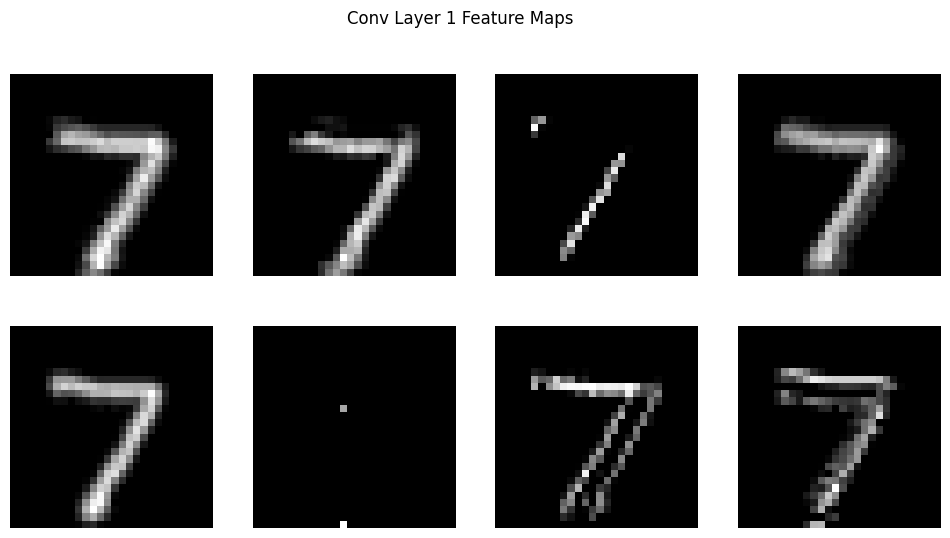

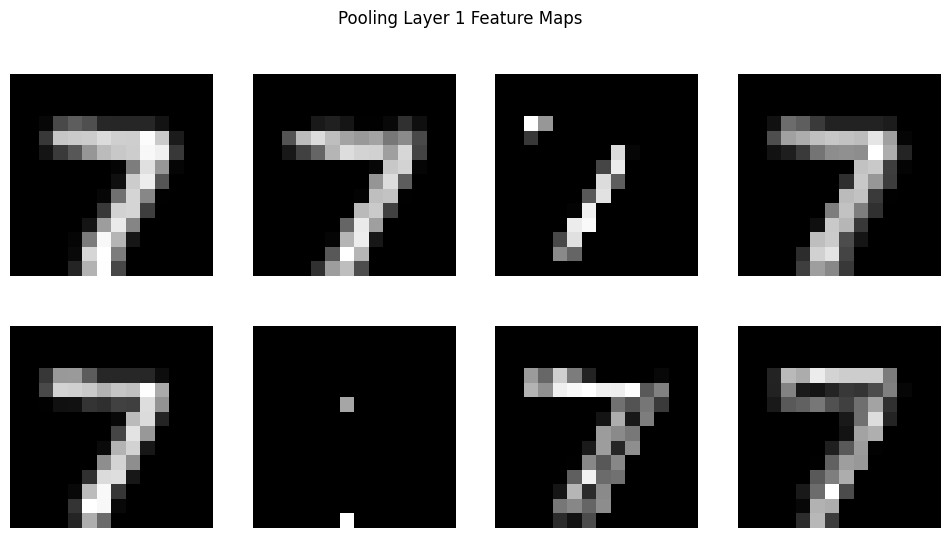

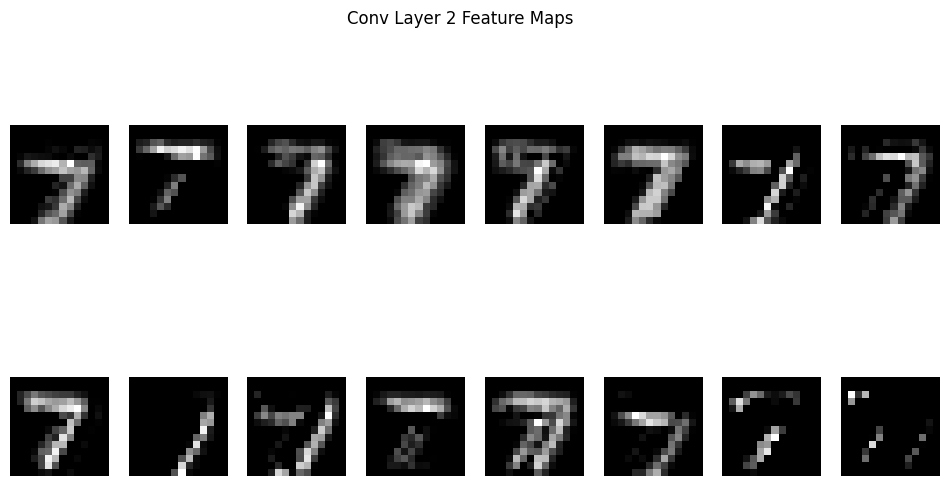

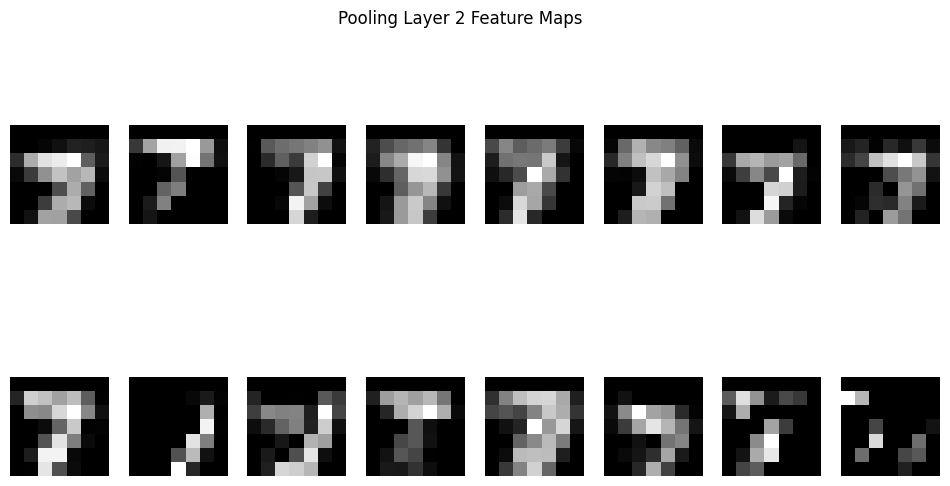

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D

# 1. Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 2. Build CNN
input_img = Input(shape=(28, 28, 1))

conv1 = Conv2D(8, (3,3), activation='relu', padding='same')(input_img)
pool1 = MaxPooling2D((2,2))(conv1)

conv2 = Conv2D(16, (3,3), activation='relu', padding='same')(pool1)
pool2 = MaxPooling2D((2,2))(conv2)

model = Model(inputs=input_img, outputs=[conv1, pool1, conv2, pool2])

# 3. Pick one test image
img = x_test[0].reshape(1, 28, 28, 1)

# 4. Get feature maps
feature_maps = model.predict(img)

# 5. Function to plot feature maps
def plot_feature_maps(feature_map, title):
    num_filters = feature_map.shape[-1]
    size = feature_map.shape[1]

    plt.figure(figsize=(12, 6))
    for i in range(num_filters):
        ax = plt.subplot(2, num_filters//2, i+1)
        plt.imshow(feature_map[0, :, :, i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# 6. Visualize each layer
plot_feature_maps(feature_maps[0], "Conv Layer 1 Feature Maps")
plot_feature_maps(feature_maps[1], "Pooling Layer 1 Feature Maps")
plot_feature_maps(feature_maps[2], "Conv Layer 2 Feature Maps")
plot_feature_maps(feature_maps[3], "Pooling Layer 2 Feature Maps")


The **convolutional layers** extract important visual features from the input
image in the form of feature maps.

In the first convolution layer, the feature maps capture basic patterns such as:

* Edges
* Lines
* Simple textures

These appear as highlighted strokes resembling parts of the digit.

In the second convolution layer, the feature maps become more abstract and represent:

* More complete shapes
* Digit-specific patterns

**This shows hierarchical feature learning.**

The **pooling layers** reduce spatial dimensions (from 28×28 → 14×14 → 7×7), which:

* Reduces computation
* Removes unnecessary details
* Retains only important features

Pooling also introduces slight blurring, indicating loss of fine details but preservation of structure.

Some feature maps appear almost blank, showing that:

* Not all filters are activated for every input
* Different filters detect different patterns

As depth increases:

* Feature maps become less interpretable visually
* But more meaningful for classification